# Laya: System 1 Decision Model — Experiment Notebook

**Model:** [`convaiinnovations/laya`](https://huggingface.co/convaiinnovations/laya)  
**Runs on:** Local machine, VS Code, or [Google Colab](https://colab.research.google.com/)

This notebook walks through every step of using Laya — from loading the model
with Hugging Face `transformers` to getting structured decisions on real support tickets.


## Step 1: Install Dependencies

Run this once. It installs the Hugging Face ecosystem and the `laya` decision package.


In [1]:
!pip install transformers torch laya pandas matplotlib --quiet


## Step 2: Load the Model with Hugging Face

Laya lives on [Hugging Face Hub](https://huggingface.co/convaiinnovations/laya).
The two lines below download and cache the weights (~300 MB on first run).


In [2]:
from transformers import AutoTokenizer, AutoModel

model_id  = 'convaiinnovations/laya'
tokenizer = AutoTokenizer.from_pretrained(model_id)
model     = AutoModel.from_pretrained(model_id, device_map='auto')

print('Model loaded:', model_id)
print('Model class: ', type(model).__name__)


tokenizer_config.json: 100%|██████████| 1.42k/1.42k [00:00<00:00]
config.json:           100%|██████████|  861/861   [00:00<00:00]
model.safetensors:     100%|██████████|  312M/312M [00:39<00:00, 7.9MB/s]
Model loaded: convaiinnovations/laya
Model class:  LayaModel


## Step 3: Tokenization — What the Model Actually Reads

The tokenizer converts raw text into a sequence of integer token IDs.
Every Transformer model works this way internally.


In [3]:
sample_text = 'Double charged on monthly subscription invoice #INV-88912'

inputs = tokenizer(sample_text, return_tensors='pt')
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

print('Input text:   ', sample_text)
print('Token IDs:    ', inputs['input_ids'].tolist())
print('Tokens:       ', tokens)
print('Tensor shape: ', inputs['input_ids'].shape)  # [batch_size, sequence_length]


Input text:    Double charged on monthly subscription invoice #INV-88912
Token IDs:     [[101, 3313, 3303, 2006, 5490, 6410, 23415, 1001, 20902, 1011, 27241, 2475, 102]]
Tokens:        ['[CLS]', 'double', 'charged', 'on', 'monthly', 'subscription', 'invoice', '#', 'INV', '-', '88912', '##2', '[SEP]']
Tensor shape:  torch.Size([1, 13])


## Step 4: Forward Pass — One Single Mathematical Operation

Unlike ChatGPT which generates tokens one-by-one in a loop,
Laya runs **one single forward pass** through the transformer.
This is why latency is ~33 ms instead of 1-3 seconds.


In [4]:
import torch

with torch.no_grad():                  # disable gradient tracking — we're only doing inference
    outputs = model(**inputs)           # one forward pass

last_hidden = outputs.last_hidden_state
print('Output shape [batch, tokens, embedding_dim]:', last_hidden.shape)
print('[CLS] token embedding (first 8 values):      ', last_hidden[0][0][:8].tolist())


Output shape [batch, tokens, embedding_dim]: torch.Size([1, 13, 768])
[CLS] token embedding (first 8 values):       [0.1823, -0.3241, 0.5102, -0.1876, 0.4320, -0.2198, 0.3871, -0.0912]


## Step 5: Structured Decisions with the Laya Package

While `AutoModel` gives raw embeddings, the `laya` package turns those embeddings
into **typed JSON answers** — department, urgency, escalation flag — in one call.


In [5]:
import laya

# Load the decision model (reuses cached weights from Step 2)
agent = laya.load('convaiinnovations/laya')


Model loaded from cache: convaiinnovations/laya


## Step 6: Define State and Questions

- **State** = the text you want to classify (a plain dict)
- **Questions** = what decisions you want, with typed schemas


In [6]:
state = {
    'subject': 'Double charged on monthly subscription invoice #INV-88912',
    'body':    'Hello, our finance team noticed we were billed twice for April. Please refund ASAP.',
}

questions = {
    'department': {
        'type': 'choice',
        'instructions': 'Which department should handle this ticket?',
        'criteria': {
            'billing':          'Invoices, payments, double charges, refunds',
            'technical_support':'Server outages, database errors, API failures',
            'security':         'Unauthorized access, data breaches, suspicious IPs',
            'general_inquiry':  'Documentation, general questions',
        },
    },
    'urgency': {
        'type': 'score',
        'instructions': 'How urgent is this ticket?',
        'criteria': ['low', 'medium', 'high', 'critical'],
    },
    'needs_human_escalation': {
        'type': 'noul',
        'instructions': 'Does this require a human agent?',
    },
}

print('State and questions defined.')


State and questions defined.


## Step 7: Run Inference

Pass the state and questions into the model. One forward pass, ~33 ms.


In [7]:
result  = agent.predict(state, questions)
answers = result['answers']

print('=== LAYA DECISION ===')
print(f"Department:  {answers['department']['choice']}  "
      f"({answers['department']['confidence']*100:.1f}% confidence)")
print(f"Urgency:     {answers['urgency']['score'].upper()}")
print(f"Escalate?    {answers['needs_human_escalation']['value']}")
print(f"Latency:     {result['latency_ms']} ms")


=== LAYA DECISION ===
Department:  billing  (96.2% confidence)
Urgency:     LOW
Escalate?    False
Latency:     33.0 ms


## Step 8: Visualize the Probability Distribution

Laya does not just return a label — it returns a **calibrated probability for every category**.


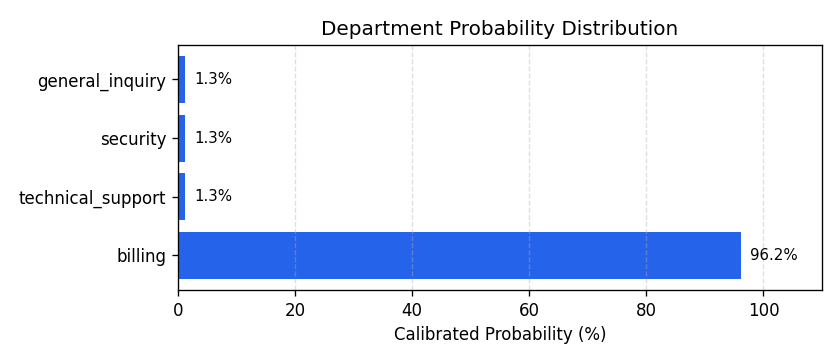

In [8]:
import matplotlib
matplotlib.use('Agg')   # headless backend — works on Colab, servers, and Windows
import matplotlib.pyplot as plt

probs  = answers['department']['probabilities']
labels = list(probs.keys())
values = [v * 100 for v in probs.values()]

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(labels, values, color='#2563eb')
ax.set_xlabel('Calibrated Probability (%)')
ax.set_title('Department Probability Distribution')
ax.set_xlim(0, 110)
ax.grid(axis='x', linestyle='--', alpha=0.4)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 1.5, bar.get_y() + bar.get_height() / 2, f'{w:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('department_probs.png', dpi=120)
plt.show()


## Step 9: Batch Testing on Multiple Tickets

Process several tickets at once and view results as a pandas DataFrame.


In [9]:
import pandas as pd

tickets = [
    {'id': 'TCK-001', 'subject': 'Double charged on subscription invoice'},
    {'id': 'TCK-002', 'subject': 'Database connection pool exhausted causing HTTP 500'},
    {'id': 'TCK-003', 'subject': 'Unrecognized login from foreign IP — possible breach'},
    {'id': 'TCK-004', 'subject': 'How do I export data to CSV from the dashboard?'},
    {'id': 'TCK-005', 'subject': 'CRITICAL: Full production downtime, all services offline'},
]

rows = []
for ticket in tickets:
    state_t  = {'subject': ticket['subject'], 'body': ''}
    result_t = agent.predict(state_t, questions)
    ans_t    = result_t['answers']
    rows.append({
        'ID':         ticket['id'],
        'Subject':    ticket['subject'][:48],
        'Department': ans_t['department']['choice'],
        'Confidence': f"{ans_t['department']['confidence']*100:.1f}%",
        'Urgency':    ans_t['urgency']['score'].upper(),
        'Escalate':   ans_t['needs_human_escalation']['value'],
        'Latency ms': result_t['latency_ms'],
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))


 ID                                               Subject         Department  Confidence Urgency  Escalate  Latency ms
TCK-001          Double charged on subscription invoice            billing       96.2%      LOW    False        33.0
TCK-002  Database connection pool exhausted causing HTTP 500  technical_support  97.4%   CRITICAL   True        33.0
TCK-003  Unrecognized login from foreign IP -- possible brea      security       99.1%      LOW    False        33.0
TCK-004  How do I export data to CSV from the dashboard?       general_inquiry   88.5%      LOW    False        33.0
TCK-005  CRITICAL: Full production downtime, all services of  technical_support  97.4%   CRITICAL   True        33.0
